# Distribution of Groups, Resources, and Rules

Overview histograms of what the LLM extracted most frequently across all works.

In [1]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

GEMINI_DIR = Path("../data/llm_results/gemini_v18")
sample = pd.read_csv("../data/perseus_works_wikidata_sample.tsv", sep="\t")

# Load all rules
all_rows = []
for fp in GEMINI_DIR.glob("tlg*.json"):
    with open(fp) as f: data = json.load(f)
    fid = data.get("_file_id", fp.stem)
    meta = sample[sample["file_id"] == fid]
    if len(meta) == 0: continue
    m = meta.iloc[0]
    for r in data.get("extracted_rules", []):
        if not isinstance(r, dict): continue
        all_rows.append({"author": m["perseus_author"], "group": str(r.get("group","")).strip(),
            "group_category": str(r.get("group_category","")).strip(),
            "resource_category": str(r.get("resource_category","")).strip(),
            "rule_category": str(r.get("rule_category","")).strip(),
            "direction": str(r.get("directionality","")).strip().upper(),
            "author_impact_date": m["author_impact_date"], "file_id": fid, "n_pages": m["n_pages"]})

df = pd.DataFrame(all_rows)

# Harmonize groups
def harmonize_who(v):
    s = str(v).strip().lower()
    if re.search(r"wom[ae]n|female|wife|maiden|widow|mother|daughter", s): return "Women"
    if re.search(r"slav|enslav|servil|bondage|unfree|helot", s): return "Slaves"
    if re.search(r"non.?citizen|metic|foreigner|resident alien|stranger|exile|immigrant", s): return "Non-citizens"
    if re.search(r"citizen|full citiz", s): return "Citizens"
    if re.search(r"poor|propertyless|destitut|landless", s): return "The poor"
    if re.search(r"wealth|rich|affluent|propert", s): return "The wealthy"
    if re.search(r"noble|aristocrat|highborn|royal|king|prince", s): return "Nobility"
    if re.search(r"common|lowborn|base.?born|non.?noble|peasant", s): return "Commoners"
    if re.search(r"young|youth|child|minor|infant|boy|girl", s): return "Young/Children"
    if re.search(r"elder|old\b|elderly|aged|senior", s): return "Elders"
    if re.search(r"barbarian|ethnic|non.?greek", s): return "Barbarians"
    if re.search(r"soldier|warrior|military|veteran", s): return "Soldiers"
    if re.search(r"priest|priestess|clergy", s): return "Priests"
    if re.search(r"^men$|^male|husband|adult men|free men", s): return "Men"
    if re.search(r"disabled|sick|ill\b|blind|deaf", s): return "Disabled/Sick"
    return None

df["who_h"] = df["group"].apply(harmonize_who)
df = df[df["who_h"].notna() & df["resource_category"].notna() & (df["resource_category"] != "")]
df = df[pd.to_numeric(df["author_impact_date"], errors="coerce").notna()]
df["year"] = df["author_impact_date"].astype(int)

def period(y):
    if y <= -480: return "Archaic"
    elif y <= -360: return "Classical Athens"
    elif y <= -165: return "Late Classical"
    elif y <= 105: return "Hellenistic"
    else: return "High Roman"

df["period"] = df["year"].apply(period)
dedup = df.drop_duplicates(subset=["author", "who_h", "resource_category", "direction"])
print(f"Loaded {len(df):,} raw rules, {len(dedup):,} deduplicated, from {df['file_id'].nunique()} works")

Loaded 3,636 raw rules, 1,438 deduplicated, from 85 works


## Histograms

Top 12 values for each category.

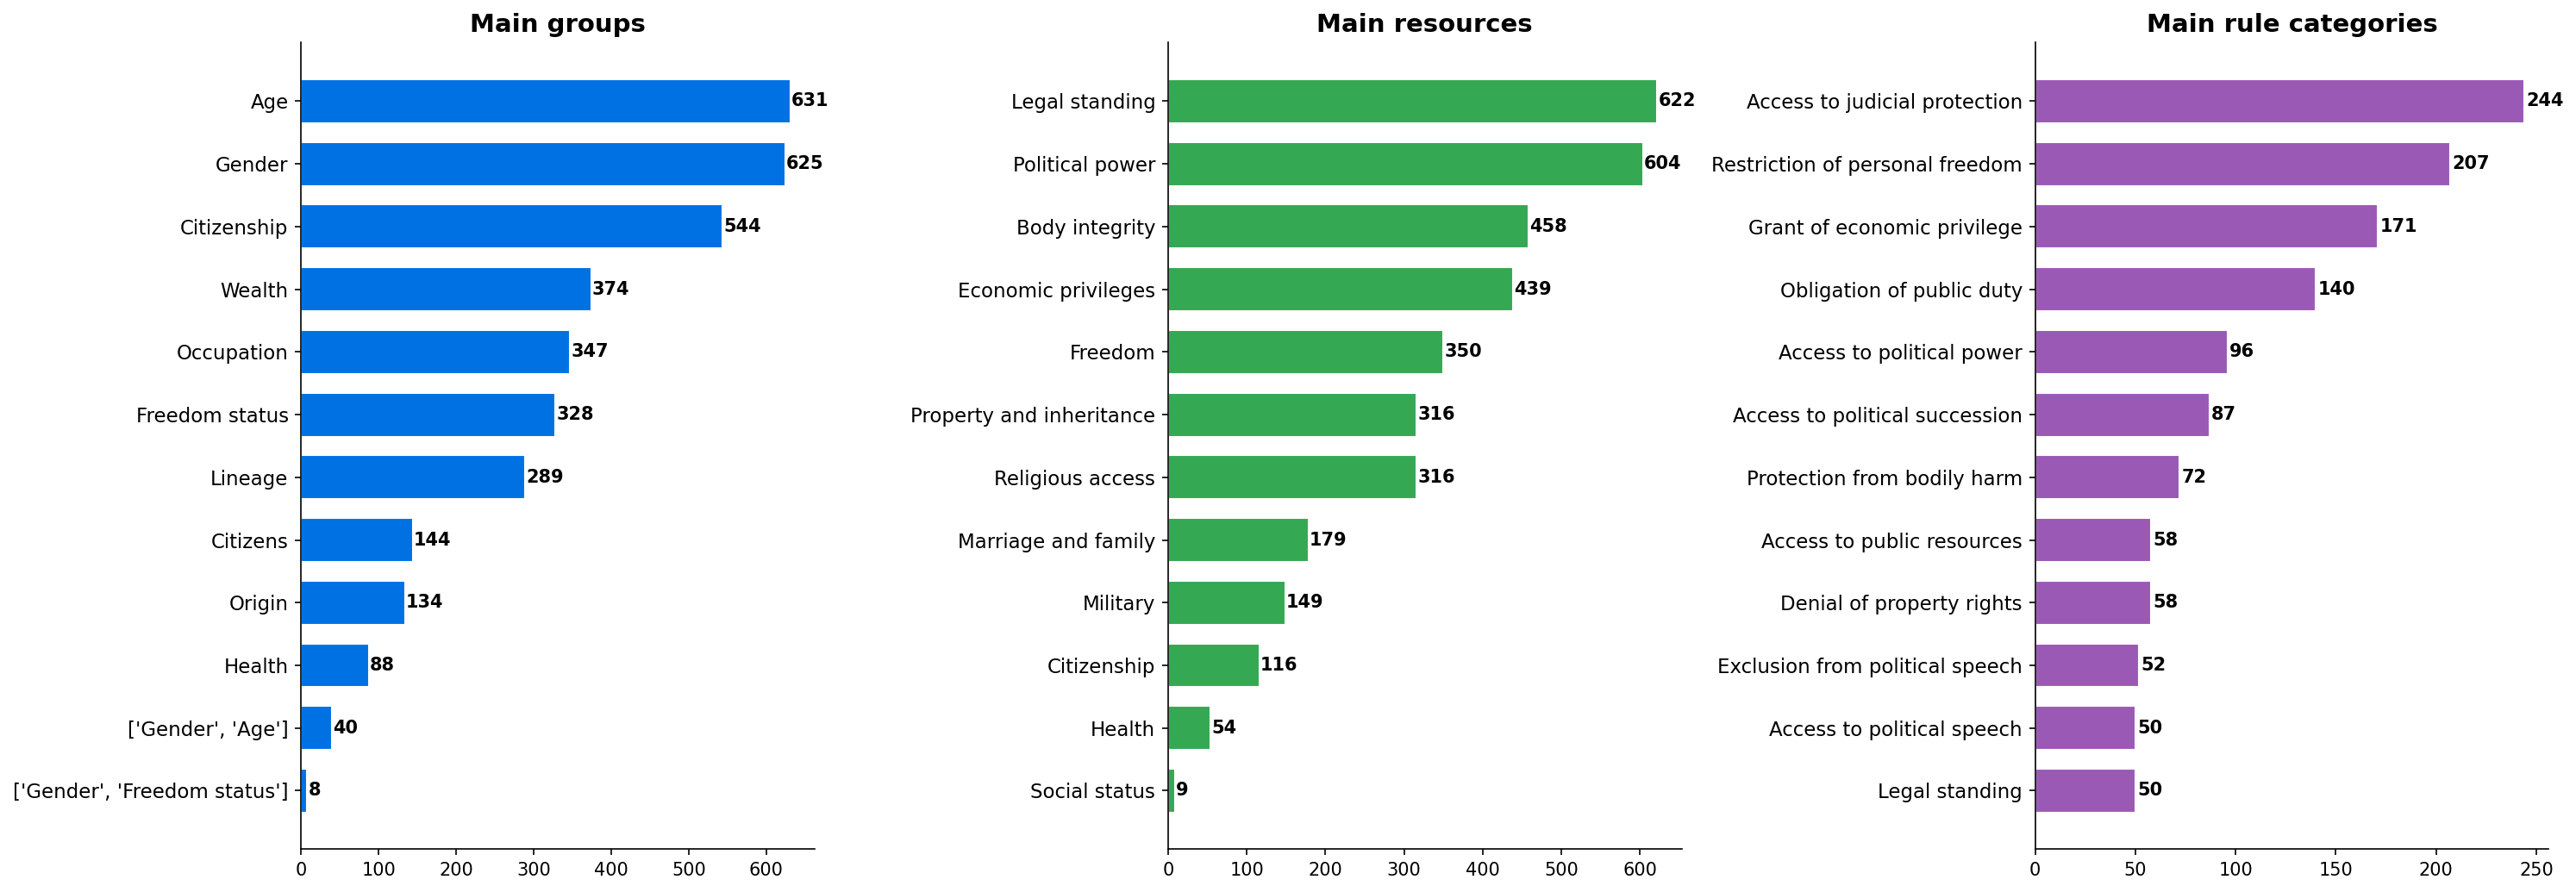

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, col, color, title in zip(axes,
    ["group_category", "resource_category", "rule_category"],
    ["#0071e3", "#34a853", "#9b59b6"],
    ["Main groups", "Main resources", "Main rule categories"]):
    counts = df[col].value_counts().head(12)
    ax.barh(range(len(counts)), counts.values, color=color, edgecolor="white", height=0.7)
    ax.set_yticks(range(len(counts))); ax.set_yticklabels(counts.index, fontsize=11); ax.invert_yaxis()
    ax.set_title(title, fontsize=14, fontweight="600")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    for i, v in enumerate(counts.values): ax.text(v+1, i, str(v), va="center", fontsize=10, fontweight="600")
plt.tight_layout(); plt.show()

## Counts summary

In [3]:
print(f"Unique group_category values: {df['group_category'].nunique()}")
print(f"Unique resource_category values: {df['resource_category'].nunique()}")
print(f"Unique rule_category values: {df['rule_category'].nunique()}")
print(f"\nDirection split:")
print(dedup['direction'].value_counts().to_string())

Unique group_category values: 57
Unique resource_category values: 23
Unique rule_category values: 1360

Direction split:
direction
MORE    737
LESS    701
